# Lab 02 — Detectors

Lab 01 decided what gets scored and published it. This lab loads that contract, recomputes none of
it, and adds the other half of the pipeline: detectors that consume a representation, and the
arithmetic for choosing between them.

- **Every method returns a score on its own scale,** so none can be compared by its raw number.
- **They are compared at an equal alert budget** — the top 1% of each score.
  - That asks the only question an on-call rota cares about: at the same volume of pages, which one
    catches more?

## What you should be able to do at the end

1. Consume a feature contract and fail loudly when it does not hold.
2. Run one detector family across three framings and read a single table.
3. Say what carrying state buys a detector, and what it costs.
4. Compose many features into one score, and spot the failure a score cap hides inside it.
5. Name what each method costs to keep running, not just what it catches.

## Step 1 — Libraries and figure settings

Every figure setting in this notebook is made here and nowhere else. No cell below sets a font
size, a line width, a marker size or a colour.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import scipy
import matplotlib
import matplotlib.pyplot as plt
from cycler import cycler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor

# Same meanings as Lab 01: blue is the measured signal, orange a baseline or a ground-truth
# window, purple a derived score, red an alert or a limit, green a peer method.
C = {"signal": "#3B7DD8", "baseline": "#E0752D", "score": "#7A5AC7",
     "alert": "#D6455D", "truth": "#FF9F1C", "peer": "#2E9E7B", "muted": "#9AA4B0"}
PORT_C = ["#3B7DD8", "#E0752D", "#2E9E7B", "#7A5AC7", "#B04A6E"]

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.figsize": (14, 4.6),
    "font.size": 14,
    "axes.titlesize": 16, "axes.titlelocation": "left", "axes.titleweight": "bold",
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 13, "ytick.labelsize": 13,
    "figure.titlesize": 18,
    "lines.linewidth": 1.4, "lines.markersize": 7,
    "scatter.edgecolors": "white",
    "axes.prop_cycle": cycler(color=PORT_C),
    "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.autolayout": True,
})
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 80)

for m in (np, pd, scipy, matplotlib):
    print(f"{m.__name__:12} {m.__version__}")

numpy        2.4.6
pandas       3.0.3
scipy        1.17.1
matplotlib   3.10.9


## Step 2 — Load what Lab 01 published

Two files. `features.csv` is one row per sample with every column a detector might score;
`feature_spec.json` is every number and no data. Nothing here recomputes a feature, and the
assertions below are the reason that is safe: a frame that does not match the spec stops the
notebook rather than quietly scoring the wrong thing.

In [2]:
ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "environments").is_dir():
    ROOT = ROOT.parent
OUT = ROOT / "outputs" / "workshop"

SPEC = json.loads((OUT / "feature_spec.json").read_text())
df = pd.read_csv(OUT / "features.csv", parse_dates=["timestamp"])
df = df.sort_values(["port_id", "timestamp"]).reset_index(drop=True)

# The contract, checked rather than trusted. An unmet precondition is a hard stop here, because a
# missing column surfaces four steps later as an unexplained recall loss with the cause long gone.
missing = [c for c in SPEC["frame"]["columns"] if c not in df.columns]
assert not missing, f"features.csv is missing {missing} — re-run Lab 01 Step 18"
assert len(df) == SPEC["frame"]["rows"], f"{len(df)} rows, spec says {SPEC['frame']['rows']}"

FEATURES = SPEC["features"]["all"]
SCORABLE = SPEC["features"]["scorable"]
DEGENERATE = SPEC["features"]["degenerate"]
SCALERS = SPEC["scalers"]

CADENCE = SPEC["data_contract"]["cadence_seconds"]
PERIOD = SPEC["data_contract"]["period_samples"]
DAYS = SPEC["data_contract"]["span_days"]
# Counters are totals over a 5-minute bucket, so a timestamp names an interval rather than an
# instant. Every shaded window below is widened by HALF so it covers the samples it contains
# instead of only their centres.
HALF = pd.Timedelta(seconds=CADENCE / 2)

print(f"{len(df):,} rows | cadence {CADENCE:.0f}s | period {PERIOD} samples | {DAYS:.0f} days")
print(f"{len(SCORABLE)} scorable, {len(DEGENERATE)} degenerate | {len(SCALERS)} fitted scalers")
print(f"residual columns shipped for: {', '.join(SPEC['features']['residual_of'])}")
df[["timestamp", "port_id", "port_role", "traffic_bps", "resid_traffic_bps",
    "is_train", "event_label"]].head()

43,200 rows | cadence 300s | period 288 samples | 30 days
7 scorable, 6 degenerate | 70 fitted scalers
residual columns shipped for: traffic_bps, packets_pps, avg_pkt_bytes, broadcast_ratio, multicast_ratio, nonucast_ratio, tx_ratio


,timestamp,port_id,port_role,traffic_bps,resid_traffic_bps,is_train,event_label
0,2026-02-01 00:00:00,port-id7427,wan-primary,116229.412000,486740.241214,True,normal
1,2026-02-01 00:05:00,port-id7427,wan-primary,101633.060800,458021.902447,True,normal
2,2026-02-01 00:10:00,port-id7427,wan-primary,121596.794667,497223.099867,True,normal
3,2026-02-01 00:15:00,port-id7427,wan-primary,123970.989067,467082.465763,True,normal
4,2026-02-01 00:20:00,port-id7427,wan-primary,92873.944800,421984.744037,True,normal


## Step 3 — Parameters

Almost all of them come from the spec, because they were measured in Lab 01 and re-choosing them
here would mean two answers to one question. Exactly one number is this lab's own, and it is the
one Lab 01 had no way to decide: the alert budget.

The two default ports are deliberately different cases. `port-id7431` carries a **contextual**
anomaly, a nightly bulk transfer at the level of an ordinary weekday afternoon, and `port-id7430`
carries an **absolute** one, a daytime surge. They diverge from Step 5 onward.

In [3]:
# ---- from the spec: measured in Lab 01, not re-chosen here -----------------------------
PORTS = SPEC["representations"]["model_ports"]
COLUMNS = [SPEC["representations"]["model_column"]]
ANOMALY_TYPES = SPEC["representations"]["model_events"]
TRAIN_FRAC = SPEC["representations"]["train_frac"]
N_INPUT = SPEC["representations"]["sliding_window_samples"]
THRESHOLD = SPEC["baseline"]["threshold"]
CAP = SPEC["baseline"]["score_cap"]

# ---- this lab's own decision -----------------------------------------------------------
BUDGET = 0.99          # alert on the top 1% of any score, so methods on different scales compare
# ----------------------------------------------------------------------------------------

print(f"ports {[p[-4:] for p in PORTS]} on {COLUMNS[0]} | train {TRAIN_FRAC:.0%} | "
      f"sliding window {N_INPUT} ({N_INPUT * CADENCE / 3600:.0f} h) | "
      f"cutoff {THRESHOLD:g} | budget {BUDGET}")
print(f"targets: {', '.join(ANOMALY_TYPES)}")

ports ['7431', '7430'] on traffic_bps | train 70% | sliding window 36 (3 h) | cutoff 4 | budget 0.99
targets: large_file_backup, business_traffic_growth, abnormal_device_sender


## Step 4 — Tools

`series_of` pulls one port into the univariate frame every model works on and carries Lab 01's
residual alongside the raw value, `scaled` applies the scaler from the spec without refitting
anything, `plot_series` draws a signal with ground truth and alerts, and `evaluate` cuts any score
at the shared budget and scores it.

In [4]:
def series_of(port, col=None, data=None):
    """One port as a time-ordered frame with `value`, `resid` and a boolean `target`.

    `resid` is Lab 01's deseasonalised column, read rather than recomputed. `target` is True on the
    event types in ANOMALY_TYPES, which is what every score is measured against. The index is reset,
    so a numpy score of the same length aligns.
    """
    data = df if data is None else data
    col = COLUMNS[0] if col is None else col
    g = data[data["port_id"] == port].sort_values("timestamp").reset_index(drop=True)
    return g.assign(value=g[col], resid=g[f"resid_{col}"].fillna(0.0),
                    target=g["event_label"].isin(ANOMALY_TYPES))


def scaled(values, port, col):
    """Apply the scaler Lab 01 fitted on the training half. Nothing is refitted in this lab.

    The spec carries one scaler per shipped column, so a column this lab reads is a column whose
    scale was set without ever seeing the test period.
    """
    sc = SCALERS[f"{port}|{col}"]
    return (np.asarray(values, dtype=float) - sc["mean"]) / sc["scale"]


def sliding_windows(x, n_input=None):
    """Rows of `n_input` consecutive values, as in Lab 01 Step 17. A view, not a copy."""
    n_input = N_INPUT if n_input is None else n_input
    return np.lib.stride_tricks.sliding_window_view(np.asarray(x, dtype=float), n_input)


def target_runs(g):
    """Contiguous True runs of `target` as (start, end) timestamp pairs, widened by HALF."""
    idx = np.flatnonzero(g["target"].to_numpy())
    if idx.size == 0:
        return []
    brk = np.flatnonzero(np.diff(idx) > 1)
    starts, ends = np.r_[idx[0], idx[brk + 1]], np.r_[idx[brk], idx[-1]]
    return [(g["timestamp"].iloc[a] - HALF, g["timestamp"].iloc[b] + HALF)
            for a, b in zip(starts, ends)]


def evaluate(name, port, score, target, budget=None):
    """Alert on the top `budget` share of the score, then count hits against the target.

    Every method is cut at the same budget, because a matrix-profile distance and an
    IsolationForest score do not live on the same axis and only equal alert counts make them
    comparable.
    """
    budget = BUDGET if budget is None else budget
    s = pd.Series(score, dtype=float)
    thr = np.nanquantile(s.dropna(), budget)
    a = (s > thr).fillna(False).to_numpy()
    t = np.asarray(target, bool)[:len(a)]
    return {"port": port[-4:], "method": name, "alerts": int(a.sum()),
            "caught": int((a & t).sum()), "of": int(t.sum()),
            "precision": round(float((a & t).sum() / a.sum()), 3) if a.sum() else np.nan}


def plot_series(g, scores=None, budget=None, title=None, window=None):
    """The signal on top, then one panel per score with its alerts marked.

    `scores` is a dict {name: array}. `window` is a (start, end) pair; the default zooms to the
    anomaly windows plus one period on each side.
    """
    budget = BUDGET if budget is None else budget
    scores = scores or {}
    if window is None and g["target"].any():
        t = g.loc[g["target"], "timestamp"]
        pad = pd.Timedelta(seconds=CADENCE * PERIOD)
        window = (t.min() - pad, t.max() + pad)
    elif window is None:
        window = (g["timestamp"].min(), g["timestamp"].max())
    view = g["timestamp"].between(*window).to_numpy()
    mark = "." if view.sum() <= 300 else None

    n = 1 + len(scores)
    w, h = plt.rcParams["figure.figsize"]
    fig, axes = plt.subplots(n, 1, figsize=(w, h * 0.72 * n), sharex=True, squeeze=False)
    axes[0, 0].plot(g.loc[view, "timestamp"], g.loc[view, "value"],
                    marker=mark, color=C["signal"])
    axes[0, 0].set_ylabel(COLUMNS[0])

    for ax, (name, s) in zip(axes[1:, 0], scores.items()):
        s = pd.Series(s, dtype=float).reindex(range(len(g)))
        thr = np.nanquantile(s.dropna(), budget)
        ax.plot(g.loc[view, "timestamp"], s[view], color=C["score"])
        ax.axhline(thr, color=C["alert"], ls="--")
        hit = view & (s > thr).fillna(False).to_numpy()
        ax.scatter(g.loc[hit, "timestamp"], s[hit], color=C["alert"], zorder=5)
        ax.set_ylabel(name)

    for ax in axes[:, 0]:
        for a, b in target_runs(g):
            if a <= window[1] and b >= window[0]:
                ax.axvspan(max(a, window[0]), min(b, window[1]),
                           color=C["truth"], alpha=0.25, lw=0, zorder=0)
    axes[-1, 0].set_xlim(*window)
    axes[-1, 0].tick_params(axis="x", labelrotation=20)
    fig.suptitle(title or g["port_id"].iloc[0])
    plt.show()

## Step 5 — Three framings, three detectors

Lab 01 shipped three ways of presenting one column, and none of them is a detector:

- **raw** — the scaled value on its own
- **deseasonalised** — the residual after the expected shape of a day is subtracted
- **window`N_INPUT`** — a sliding window of the last `N_INPUT` values

Same three scikit-learn detectors on all three, one table.

**Where each scaling comes from matters.** The first two are shipped columns, so the spec carries
their scalers and nothing is refitted. The window matrix is not shipped — it is thirty-six
overlapping copies of a column this lab already has — so its scaling is rebuilt here from training
rows alone. That is the contract's rule: **a shipped column carries its scaler; a view rebuilds one
from training rows.** Either way, no test sample sets a scale.

In [5]:
def fit_models(train, full, seed=0):
    """Fit the three detectors on `train` and score `full`. Higher score = more anomalous.

    Each library method returns higher-is-more-normal, so every score is negated. OneClassSVM is
    fitted on every tenth training row, which keeps a quadratic-time solver inside a teaching
    notebook's patience.
    """
    return {
        "IsolationForest": -IsolationForest(n_estimators=100, random_state=seed)
                            .fit(train).score_samples(full),
        "OneClassSVM": -OneClassSVM(kernel="rbf", nu=0.01, gamma="scale")
                        .fit(train[::10]).score_samples(full),
        "LOF": -LocalOutlierFactor(n_neighbors=20, novelty=True).fit(train).score_samples(full),
    }


def framings(g, port, col=None, n_input=None, train_frac=None):
    """{name: (X, split, pad)} for the three representations Lab 01 defined."""
    col = COLUMNS[0] if col is None else col
    n_input = N_INPUT if n_input is None else n_input
    train_frac = TRAIN_FRAC if train_frac is None else train_frac
    k = int(train_frac * len(g))

    W = sliding_windows(g["value"], n_input=n_input)
    kw = int(train_frac * len(W))
    scale = W[:kw].std(axis=0)
    Xw = (W - W[:kw].mean(axis=0)) / np.where(scale == 0, 1.0, scale)

    return {
        "raw": (scaled(g["value"], port=port, col=col).reshape(-1, 1), k, 0),
        "deseasonalised": (scaled(g["resid"], port=port, col=f"resid_{col}").reshape(-1, 1), k, 0),
        f"window{n_input}": (Xw, kw, n_input - 1),
    }


rows, scores = [], {}
for port in PORTS:
    g = series_of(port=port, col=COLUMNS[0], data=df)
    for name, (X, k, pad) in framings(g, port=port, col=COLUMNS[0],
                                      n_input=N_INPUT, train_frac=TRAIN_FRAC).items():
        fitted = fit_models(X[:k], X)
        # a window's score belongs to the sample it ends on, so pad the leading samples
        fitted = {m: np.concatenate([np.full(pad, np.nan), s]) for m, s in fitted.items()}
        scores[port, name] = fitted
        for model, s in fitted.items():
            rows.append(evaluate(name=f"{name} {model}", port=port, score=s,
                                 target=g["target"], budget=BUDGET))

pd.DataFrame(rows)

,port,method,alerts,caught,of,precision
0,7431,raw IsolationForest,86,0,36,0.000
1,7431,raw OneClassSVM,87,0,36,0.000
2,7431,raw LOF,87,0,36,0.000
3,7431,deseasonalised IsolationForest,87,23,36,0.264
4,7431,deseasonalised OneClassSVM,87,4,36,0.046
5,7431,deseasonalised LOF,87,5,36,0.057
6,7431,window36 IsolationForest,87,15,36,0.172
7,7431,window36 OneClassSVM,87,0,36,0.000
8,7431,window36 LOF,87,31,36,0.356
9,7430,raw IsolationForest,86,39,40,0.453


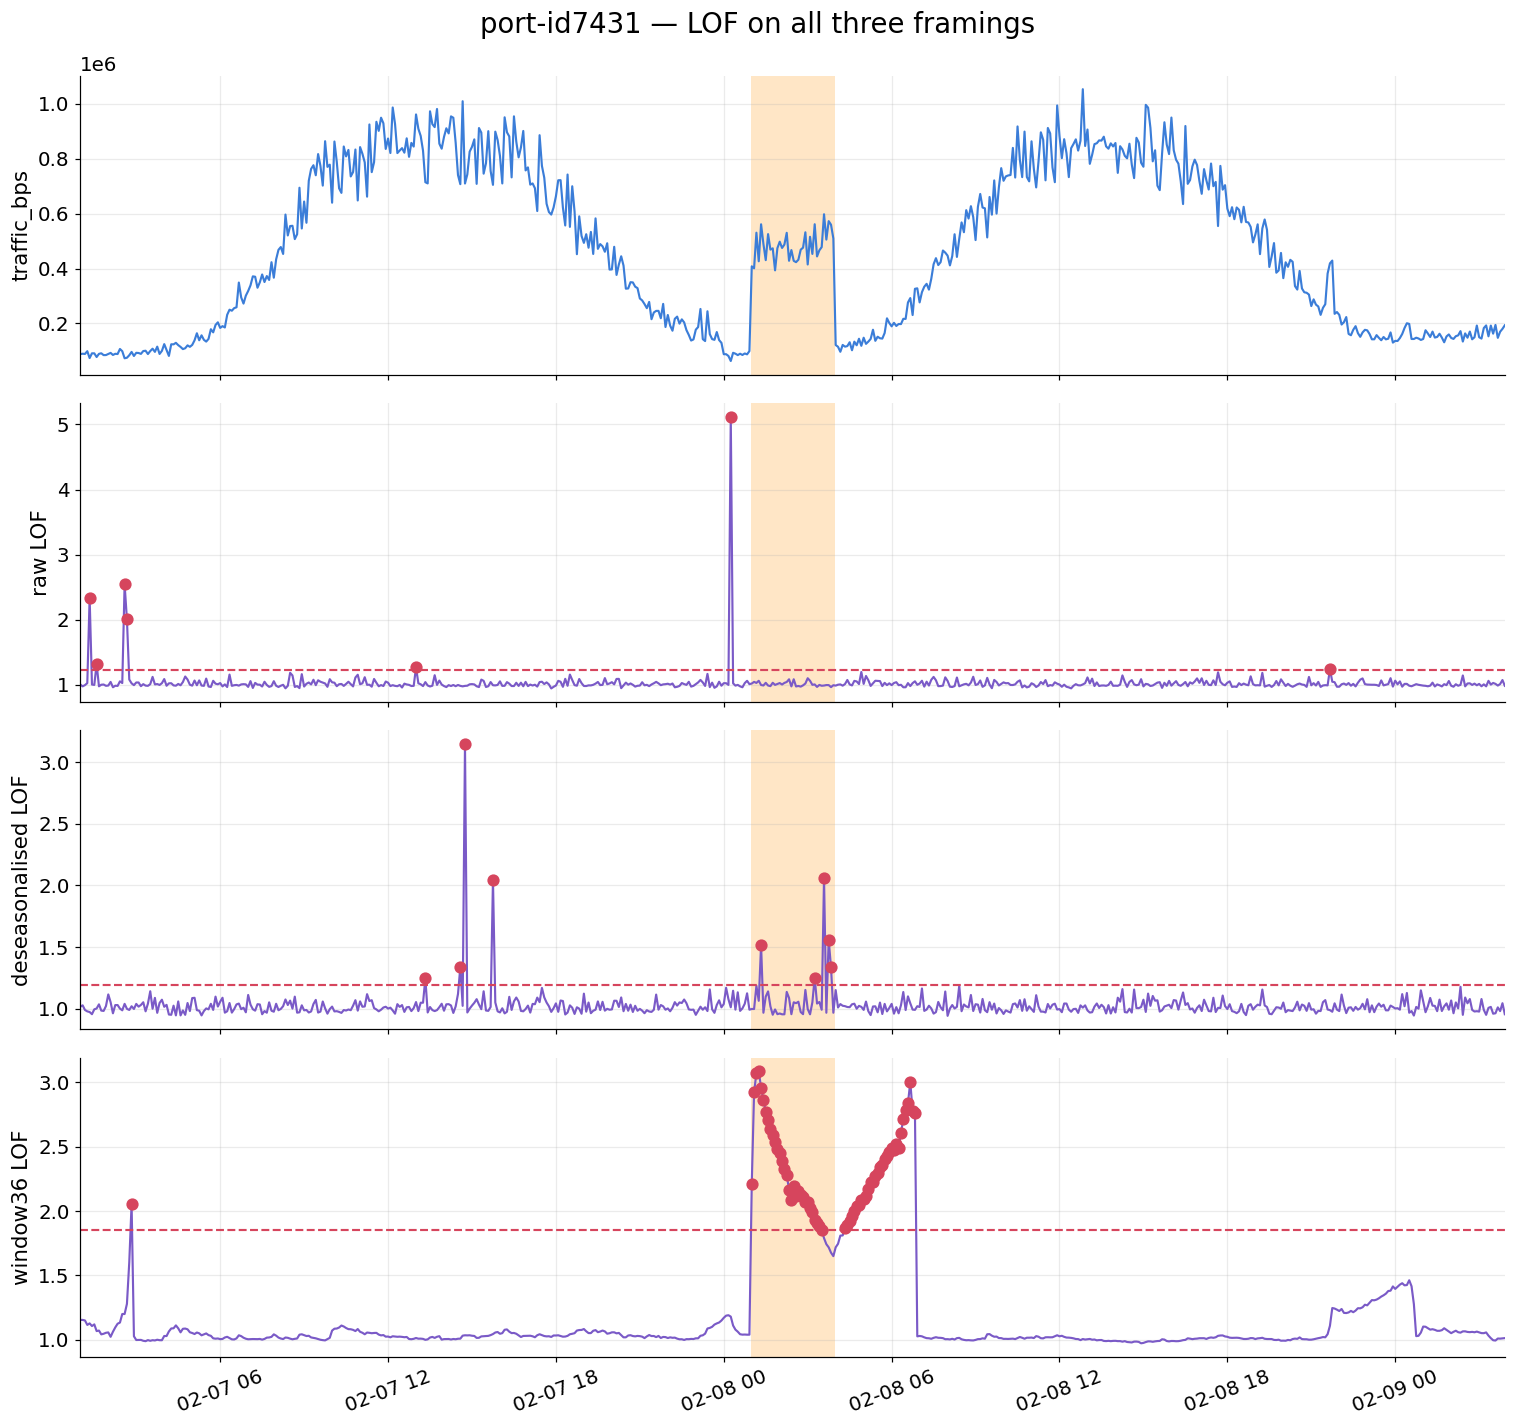

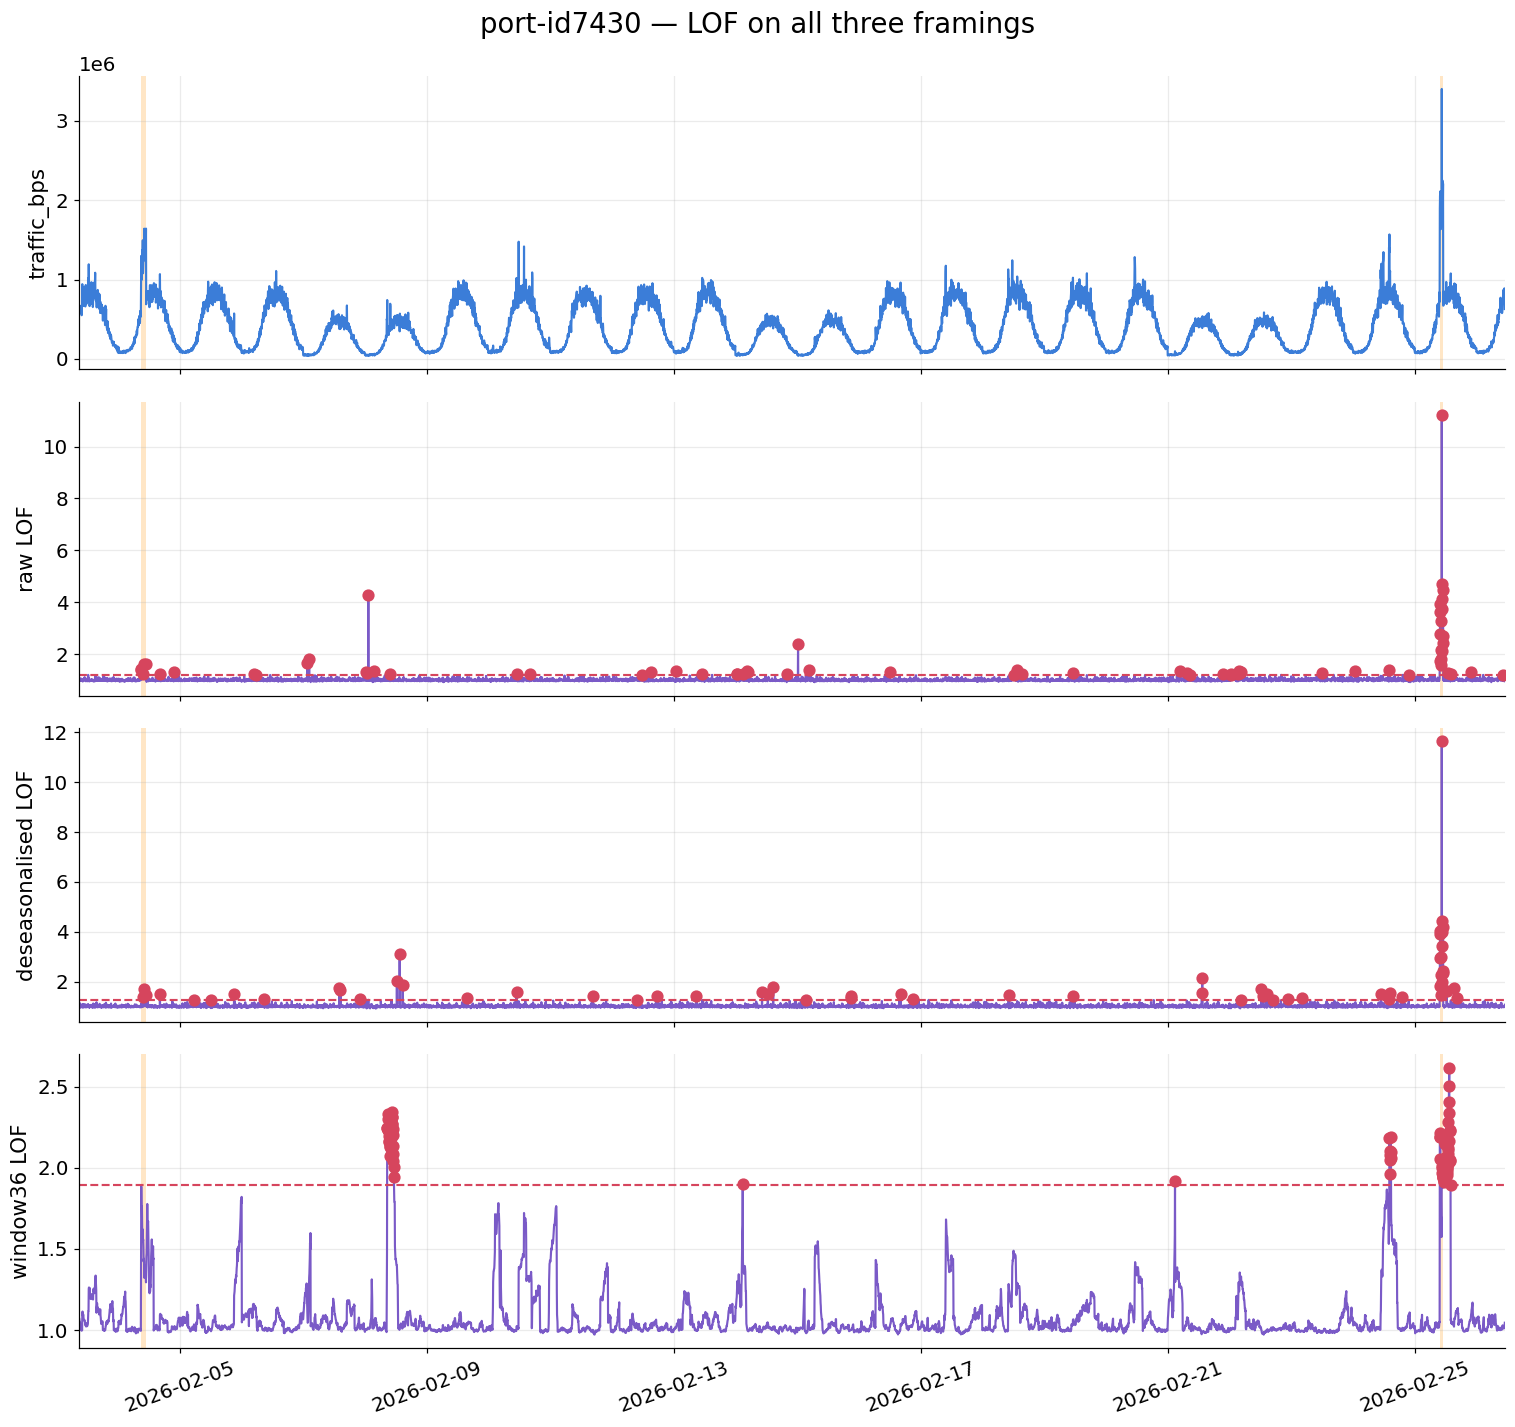

In [6]:
for port in PORTS:
    plot_series(series_of(port=port, col=COLUMNS[0], data=df),
                scores={f"{name} {m}": s
                        for name in ("raw", "deseasonalised", f"window{N_INPUT}")
                        for m, s in scores[port, name].items() if m == "LOF"},
                budget=BUDGET, title=f"{port} — LOF on all three framings")

Read the table by column, because the two ports say opposite things.

- **Absolute port — the raw framing is already near the ceiling.**
  - `IsolationForest` catches 39 of 40.
  - Deseasonalising adds the fortieth; windowing loses eleven.
  - The remedies range from marginal to harmful on a port that never needed one.
- **Contextual port — the raw framing catches nothing at all.** 0 of 36 under all three models.
  - The bulk transfer runs at the level of an ordinary weekday afternoon, at one in the morning.
  - That *is* the anomaly.
  - A model given one number and no clock only knows "high", and this is not high.

**Both remedies give the model a clock, by different routes.** The decomposition subtracts the
expected shape; the window lets the model compare shapes.

**And the model matters as much as the framing** — the half Lab 01 could not see.

- On the windowed rows of the contextual port, `OneClassSVM` catches **0** and `LOF` catches **31**.
- The widest spread in the table, and the best framing for one model is worth nothing to another.
- **So a framing and a detector are one decision, not two.**

## Step 6 — Change points: did the system move to a new level?

Everything so far asks whether a sample is far from a baseline. A change point asks whether the
process changed. A deployment moving memory from 40% to 65% produces no outlier at all, and every
point-wise detector stays silent while the system is permanently different.

**Two-window score** — compare the window before $t$ against the window after:

$$\mathrm{score}_t = \left| \mathrm{mean}(x_{t-w \ldots t}) - \mathrm{mean}(x_{t \ldots t+w}) \right|$$

It uses the future, so it is offline. Online you compare an older reference window against a recent
detection window and accept the delay.

**CUSUM** — accumulate small deviations instead of thresholding each one:

$$S_t = \max(0,\; S_{t-1} + z_t - k)$$

A persistent shift too small to trip a per-sample cutoff adds up until $S_t$ crosses `h`. `k` is the
deviation you agree to ignore; `h` is how much accumulated evidence justifies acting.

In [7]:
def two_window(x, w, online=False):
    """|mean(previous w) - mean(next w)| at every point.

    online=True compares two windows that both sit in the past, separated by a gap of w, which is
    what a live detector can actually compute. The offline form is centred on t and peaks exactly
    at the change; the online form peaks w samples later.
    """
    s = pd.Series(np.asarray(x, dtype=float))
    before = s.rolling(w, min_periods=w // 2).mean()
    after = before.shift(-w) if not online else before.shift(w)
    return (before - after).abs() if online else (after - before).abs()


def cusum(z, k=1.5, h=5.0):
    """One-sided CUSUM on a standardised series, resetting after each alarm.

    Returns (statistic, alarm mask). Without the reset the statistic ratchets upward and every
    later sample inherits the first excursion.

    The returned statistic holds the value at the moment of crossing rather than the post-reset
    zero, so a plotted peak actually touches the limit line and the alarm marker sits on it.
    """
    z = np.asarray(z, dtype=float)
    S = np.zeros(len(z))
    alarm = np.zeros(len(z), bool)
    run = 0.0
    for t in range(1, len(z)):
        run = max(0.0, run + z[t] - k)
        S[t] = run
        if run > h:
            alarm[t] = True
            run = 0.0
    return S, alarm


port = PORTS[1]                      # the port whose calendar entry claims a level shift
g = series_of(port)
level = g["value"].rolling(PERIOD, min_periods=PERIOD // 2).mean()     # for the display panel
# Applied to the raw series, not to `level`: `level` is already a rolling mean, and running a
# second one over it would smooth the very step the score exists to find.
tw = two_window(g["value"], PERIOD, online=True)

resid = g["resid"].to_numpy()                    # Lab 01 Step 16, read rather than recomputed
train = resid[:int(TRAIN_FRAC * len(resid))]
z = (resid - train.mean()) / train.std()
S, alarm = cusum(z, k=1.5, h=5.0)

peak = int(tw.idxmax())
print(f"{port}")
print(f"  two-window peak at {g['timestamp'][peak]} "
      f"({g['timestamp'][peak].day_name()}, label {g['event_label'][peak]})")
# every local maximum in the top decile, kept 12 h apart, with the weekday it fell on
v = np.nan_to_num(tw.to_numpy())
kept = []
for i in np.argsort(-v):
    if v[i] < tw.quantile(0.90):
        break
    if all(abs(i - j) > PERIOD // 2 for j in kept):
        kept.append(int(i))
print("  every top-decile peak:",
      ", ".join(f"{g['timestamp'][i]:%m-%d} {g['timestamp'][i].day_name()[:3]}"
                for i in sorted(kept)))
print(f"  CUSUM: {alarm.sum()} alarms, {int((alarm & g['target'].to_numpy()).sum())} inside a "
      f"anomaly window, {(alarm & ~g['target'].to_numpy()).sum() / DAYS:.2f} per day outside")

port-id7430
  two-window peak at 2026-02-14 23:55:00 (Saturday, label normal)
  every top-decile peak: 02-02 Mon, 02-07 Sat, 02-09 Mon, 02-14 Sat, 02-16 Mon, 02-21 Sat, 02-23 Mon, 02-28 Sat, 03-02 Mon
  CUSUM: 49 alarms, 31 inside a anomaly window, 0.60 per day outside


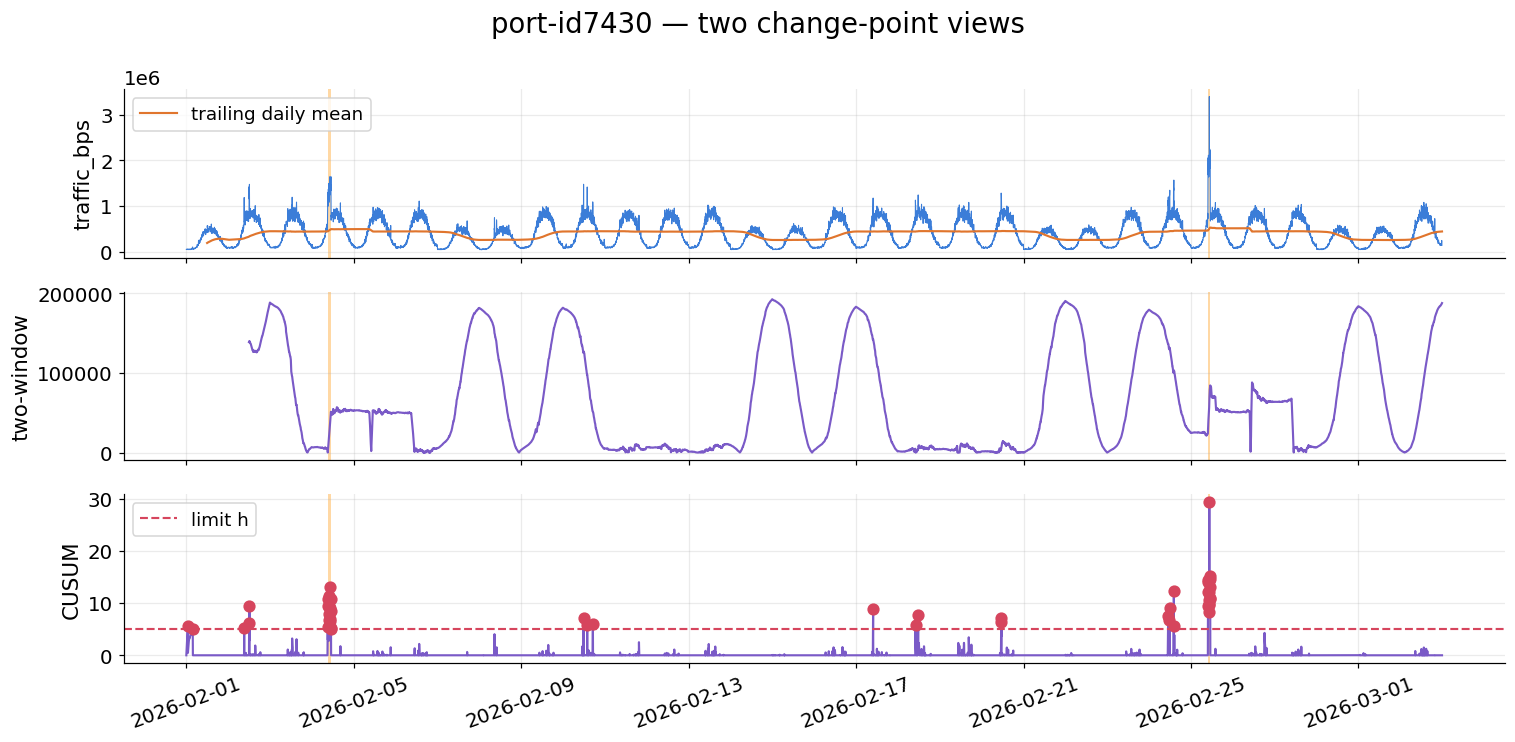

In [8]:
w, h = plt.rcParams["figure.figsize"]
fig, axes = plt.subplots(3, 1, figsize=(w, h * 1.5), sharex=True)
axes[0].plot(g["timestamp"], g["value"], lw=0.7, color=C["signal"])
axes[0].plot(g["timestamp"], level, color=C["baseline"], label="trailing daily mean")
axes[0].set_ylabel("traffic_bps")
axes[0].legend(loc="upper left")

axes[1].plot(g["timestamp"], tw, color=C["score"])
axes[1].set_ylabel("two-window")

axes[2].plot(g["timestamp"], S, color=C["score"])
axes[2].axhline(5.0, color=C["alert"], ls="--", label="limit h")
axes[2].scatter(g.loc[alarm, "timestamp"], S[alarm], color=C["alert"], zorder=5)
axes[2].set_ylabel("CUSUM")
axes[2].legend(loc="upper left")

for ax in axes:
    for a, b in target_runs(g):
        ax.axvspan(a, b, color=C["truth"], alpha=0.4, lw=0)
axes[-1].tick_params(axis="x", labelrotation=20)
fig.suptitle(f"{port} — two change-point views")
plt.show()

### A change point is not an incident

- **The two-window trace peaks on no anomaly at all.**
  - Every top-decile peak is a Saturday or a Monday at 23:55.
  - Those are the weekend boundaries — the month's biggest genuine level changes, all expected.
- **CUSUM on the deseasonalised residual behaves differently.**
  - 49 alarms, 31 inside an anomaly window, 0.60 stray alarms a day.
  - It finds a two-hour surge no single sample would have tripped.
- **That is the division of labour:** single-point rules for large spikes, cumulative methods for
  sustained small offsets.
- **The calendar disagrees with the data.**
  - `change_calendar.csv` calls CH-02 a permanent level shift.
  - The weekday 09:00–11:00 mean by week: 8.2e5, 6.9e5, 7.1e5, 8.6e5, 6.8e5. Noise, not a step.

**A detected change point is an entry point for investigation, not a verdict.** Correlate with
deployments, tickets and maintenance first.

## Step 7 — EWMA, and why a control limit is not optional

CUSUM accumulates; EWMA weights.

$$s_t = \lambda z_t + (1 - \lambda) s_{t-1}$$

- **`lambda` sets the memory,** roughly $(2-\lambda)/\lambda$ samples.
  - Small is a long memory and a smooth statistic; large approaches the raw score.
- **The trap is the scale.**
  - The EWMA of a standardised series has standard deviation $\sqrt{\lambda/(2-\lambda)}$.
  - That is 0.33 at $\lambda = 0.2$ — a third of the size the threshold was written for.
- **Dividing by the control limit puts every `lambda` back on one axis,** where 4 means what it means
  everywhere else.

In [9]:
def ewma_score(z, lam=0.2, L=1.0):
    """Geometrically weighted mean of a standardised series, rescaled onto the sigma axis.

    Dividing by L * sqrt(lam / (2 - lam)) is what lets one threshold serve every lam. Skip it and
    the statistic is a fraction of the raw score, so nothing ever crosses a cutoff of 4.
    """
    z = pd.Series(np.asarray(z, dtype=float)).fillna(0.0)
    s = z.ewm(alpha=lam, adjust=False).mean()
    limit = L * np.sqrt(lam / (2 - lam))
    return s / limit


port = PORTS[1]
g = series_of(port=port, col=COLUMNS[0], data=df)
resid = g["resid"].to_numpy()                    # Lab 01 Step 16, read rather than recomputed
train = resid[:int(TRAIN_FRAC * len(resid))]
z = (resid - train.mean()) / train.std()

rows_e = []
for lam in (0.05, 0.1, 0.2, 0.4, 0.8):
    raw = pd.Series(z).ewm(alpha=lam, adjust=False).mean()
    scaled = ewma_score(z=z, lam=lam, L=1.0)
    limit = np.sqrt(lam / (2 - lam))
    rows_e.append({"lam": lam, "memory_samples": round((2 - lam) / lam, 1),
                   "control_limit": round(float(limit), 4),
                   "implied_threshold_if_unscaled": round(4.0 / float(limit), 2),
                   "raw alerts > 4": int((raw.abs() > 4).sum()),
                   "rescaled alerts > 4": int((scaled.abs() > 4).sum())})
pd.DataFrame(rows_e)

,lam,memory_samples,control_limit,implied_threshold_if_unscaled,raw alerts > 4,rescaled alerts > 4
0,0.05,39.0,0.1601,24.98,26,2202
1,0.10,19.0,0.2294,17.44,40,1687
2,0.20,9.0,0.3333,12.00,40,807
3,0.40,4.0,0.5000,8.00,51,143
4,0.80,1.5,0.8165,4.90,63,75


**`implied_threshold_if_unscaled` is the column to read.** Comparing an unscaled EWMA against 4 is
the same as comparing the underlying z against 4 divided by the control limit: **12.0** at
λ = 0.2, **17.4** at 0.1, **25.0** at 0.05. Nothing errors, nothing warns.

- **The detector is simply running three to six times stricter than the config says,** and the two
  alert-count columns show the cost.
- **Omitting the rescale couples sensitivity to memory length,** so tuning λ for smoothness silently
  retunes the threshold. Breaking that coupling is what the control limit is for.
- **On this residual the raw statistic still fires,** because |z| goes far above 12 during an
  anomaly. On a quieter signal the same omission produces a detector that never speaks at all.

An error that is survivable on one series and fatal on another is worth a cell rather than a comment.

In [10]:
S_cusum, alarm_cusum = cusum(z=z, k=0.5, h=5.0)
ew = ewma_score(z=z, lam=0.2, L=1.0)
tw = two_window(x=g["value"], w=PERIOD, online=True)

acc = {
    "CUSUM k=0.5 h=5.0": pd.Series(alarm_cusum),
    "EWMA lam=0.2 over 4": (ew.abs() > 4),
    "two-window over q99": (tw > tw.quantile(0.99)).fillna(False),
}
tgt = g["target"].to_numpy()
rows_acc = []
for name, a in acc.items():
    m = a.reindex(range(len(g)), fill_value=False).to_numpy()
    rows_acc.append({"detector": name, "alerts": int(m.sum()),
                     "hits_in_anomaly": int((m & tgt).sum()),
                     "precision": round(float((m & tgt).sum() / max(m.sum(), 1)), 3),
                     "alerts_per_day": round(float((m & ~tgt).sum()) / DAYS, 2)})
pd.DataFrame(rows_acc)

,detector,alerts,hits_in_anomaly,precision,alerts_per_day
0,CUSUM k=0.5 h=5.0,150,34,0.227,3.87
1,EWMA lam=0.2 over 4,807,39,0.048,25.60
2,two-window over q99,83,0,0.000,2.77


Two structural notes worth more than the numbers.

- **CUSUM must run with no confirmation layer.**
  - It resets to zero the moment it signals.
  - Its statistic is above the limit for exactly one sample by construction.
  - Requiring two in a row charges it twice for a property it has, and silences it.
- **The general rule:** a confirmation layer gives a *memoryless* score persistence, so it is
  redundant on any statistic that carries state.
- **EWMA is late in both directions.**
  - It peaks after the raw score and decays more slowly.
  - It buys smoothness with delay at the start and a tail of alerts after the anomaly is over.

## Step 8 — Composing many features, and the failure hiding inside it

Scoring one column at a time answers "is this feature unusual". Operations wants "is this port
unusual", which is a composition question. The cheapest composition is the maximum absolute z across
features. Max rather than mean, because a mean dilutes: one feature screaming and six quiet averages
down to mild, while max lets any single feature clear the cutoff alone. What max discards is
agreement, since it cannot tell one feature at 12 from six features at 12.

The interesting part is what happens when the six degenerate features join in.

In [11]:
def robust_z_matrix(data=df, cols=None, ports=None, window=None, cap=50.0, floor_frac=0.05):
    """Absolute robust z for every column, per port, capped. Same length as data.

    The cap and the floor are numerical guards: without the floor a quiet stretch drives the MAD
    toward zero and any deviation scores in the thousands. Both are named here rather than buried,
    because the next cell is about what they do to the score's own distribution.
    """
    cols = SCORABLE if cols is None else cols
    ports = PORTS if ports is None else ports
    window = WINDOW if window is None else window
    mp = max(3, window // 3)
    out = {}
    for col in cols:
        z = pd.Series(np.nan, index=data.index, dtype=float)
        for pid in ports:
            gi = data.index[data["port_id"] == pid]
            prev = data.loc[gi, col].shift(1)
            c = prev.rolling(window, min_periods=mp).median()
            sc = (prev - c).abs().rolling(window, min_periods=mp).median() * 1.4826
            whole = data.loc[gi, col].to_numpy(dtype=float)
            fl = max(floor_frac * 1.4826 * np.median(np.abs(whole - np.median(whole))), 1e-12)
            z.loc[gi] = ((data.loc[gi, col] - c) / sc.fillna(fl).clip(lower=fl)).clip(-cap, cap)
        out[col] = z.abs()
    return pd.DataFrame(out, index=data.index)


CAP = 50.0            # the score cap, and the whole subject of this step
WINDOW = 12           # rolling window in samples, one hour. Lab 01 Step 9 is why
z_scorable = robust_z_matrix(data=df, cols=SCORABLE, ports=PORTS, window=WINDOW,
                             cap=CAP, floor_frac=0.05)
z_all = robust_z_matrix(data=df, cols=FEATURES, ports=PORTS, window=WINDOW,
                        cap=CAP, floor_frac=0.05)
score_scorable = z_scorable.max(axis=1)
score_all = z_all.max(axis=1)

for name, sc in [(f"max abs z over {len(SCORABLE)} scorable", score_scorable),
                 (f"max abs z over all {len(FEATURES)}", score_all)]:
    at_cap = float((sc >= CAP - 1e-9).mean())
    print(f"{name:32} at the cap {at_cap:7.2%} | q0.99 {np.nanquantile(sc.dropna(), 0.99):8.3f}"
          f" | q0.995 {np.nanquantile(sc.dropna(), 0.995):8.3f}")

max abs z over 7 scorable        at the cap   0.17% | q0.99    7.668 | q0.995   11.579
max abs z over all 13            at the cap   4.73% | q0.99   50.000 | q0.995   50.000


Read the two `q0.995` numbers.

- **Seven scorable features:** 0.17% of samples reach the cap, and the 99.5th percentile is **11.6**
  — an ordinary number, so a quantile threshold means something.
- **All thirteen:** 4.7% of samples sit at exactly **50.0**, which puts both the 99th and the 99.5th
  percentile *on* the cap, and no sample can exceed it.

**The score has not stopped working as a rule** — a cutoff of 4 still separates. **It has stopped
working as a ranking,** and that removes the foundation under everything built on ranking: quantile
thresholds, alert budgets, precision-recall curves, every sweep in this notebook.

A guard rail chosen for numerical safety changed the statistical properties of the score. That is why
a cap belongs in a spec the next stage can read, not inside a helper function.

In [12]:
tgt = df["event_label"].isin(ANOMALY_TYPES).to_numpy()
budget_rows = []
for name, sc in [("7 scorable", score_scorable), ("all 13", score_all)]:
    for rule, thr in [("abs z > 4", 4.0),
                      ("q = 0.995", float(np.nanquantile(sc.dropna(), 0.995)))]:
        m = (sc > thr).fillna(False).to_numpy()
        budget_rows.append({"columns": name, "rule": rule, "threshold": round(thr, 3),
                            "alerts": int(m.sum()), "hits_in_anomaly": int((m & tgt).sum()),
                            "alerts_per_day": round(float((m & ~tgt).sum()) / DAYS, 2)})
pd.DataFrame(budget_rows)

,columns,rule,threshold,alerts,hits_in_anomaly,alerts_per_day
0,7 scorable,abs z > 4,4.000,1464,19,48.17
1,7 scorable,q = 0.995,11.579,87,18,2.30
2,all 13,abs z > 4,4.000,3291,26,108.83
3,all 13,q = 0.995,50.000,0,0,0.00


**The `q = 0.995` row on all 13 columns is the one to sit with.** Threshold equals cap, comparison is
strict, detector emits nothing. No crash, no warning, and a dashboard built on it would have looked
healthy for as long as anyone watched.

### The ordering bug, which is the same class of failure

Score the incoming sample against the window, **then** append it. Reverse those two lines and the
code raises nothing and draws a plausible chart while destroying recall in proportion to the size of
the anomaly — the anomaly is now inside the baseline it is judged against. Measure it rather than
trusting a comment.

In [13]:
col, port = "traffic_bps", PORTS[1]
g = series_of(port=port, col=col, data=df)
v, w, mp = g["value"], WINDOW, max(3, WINDOW // 3)
tgt = g["target"].to_numpy()

rows_o = []
for kind in ("mean", "robust"):
    if kind == "mean":
        c_ok, s_ok = v.shift(1).rolling(w, min_periods=mp).mean(), v.shift(1).rolling(w, min_periods=mp).std()
        c_bug, s_bug = v.rolling(w, min_periods=mp).mean(), v.rolling(w, min_periods=mp).std()
    else:
        c_ok = v.shift(1).rolling(w, min_periods=mp).median()
        s_ok = (v.shift(1) - c_ok).abs().rolling(w, min_periods=mp).median() * 1.4826
        c_bug = v.rolling(w, min_periods=mp).median()
        s_bug = (v - c_bug).abs().rolling(w, min_periods=mp).median() * 1.4826
    ok = ((v - c_ok).abs() / s_ok.clip(lower=1e-12)).clip(upper=CAP)
    bug = ((v - c_bug).abs() / s_bug.clip(lower=1e-12)).clip(upper=CAP)
    rows_o.append({"estimator": kind,
                   "correct peak": round(float(ok[tgt].max()), 2),
                   "bug peak": round(float(bug[tgt].max()), 2),
                   "correct samples > 4": int((ok[tgt] > 4).sum()),
                   "bug samples > 4": int((bug[tgt] > 4).sum()),
                   "of": int(tgt.sum())})
pd.DataFrame(rows_o)

,estimator,correct peak,bug peak,correct samples > 4,bug samples > 4,of
0,mean,14.81,3.1,3,0,40
1,robust,11.60,11.6,9,6,40


**The same one-line error costs the mean baseline everything and the robust one a third.**

- **Mean:** peak score 14.81 → 3.10, and all three samples that cleared the cutoff stop clearing it.
  The detector goes from finding the anomaly to finding nothing.
- **Robust:** peak does not move at all; count falls 9 → 6.
- **Why:** a mean has a breakdown point of zero, so one contaminating sample moves it. A median needs
  more than half the window, and one sample in twelve is nowhere near it.

**That is the opposite of the usual advice.** Robustness is sold as protection against dirty data.
Here it also bought protection against a coding error — and neither the test suite nor the chart
would have told you which implementation you were running.

**Both failures in this step share a shape:** nothing raised, nothing logged, output still plausible.
A pipeline that fails loudly is a pipeline you can fix.

## Step 9 — Everything side by side

Every point-wise method at the same alert budget, so the comparison is about the method rather
than about how loudly it was tuned.

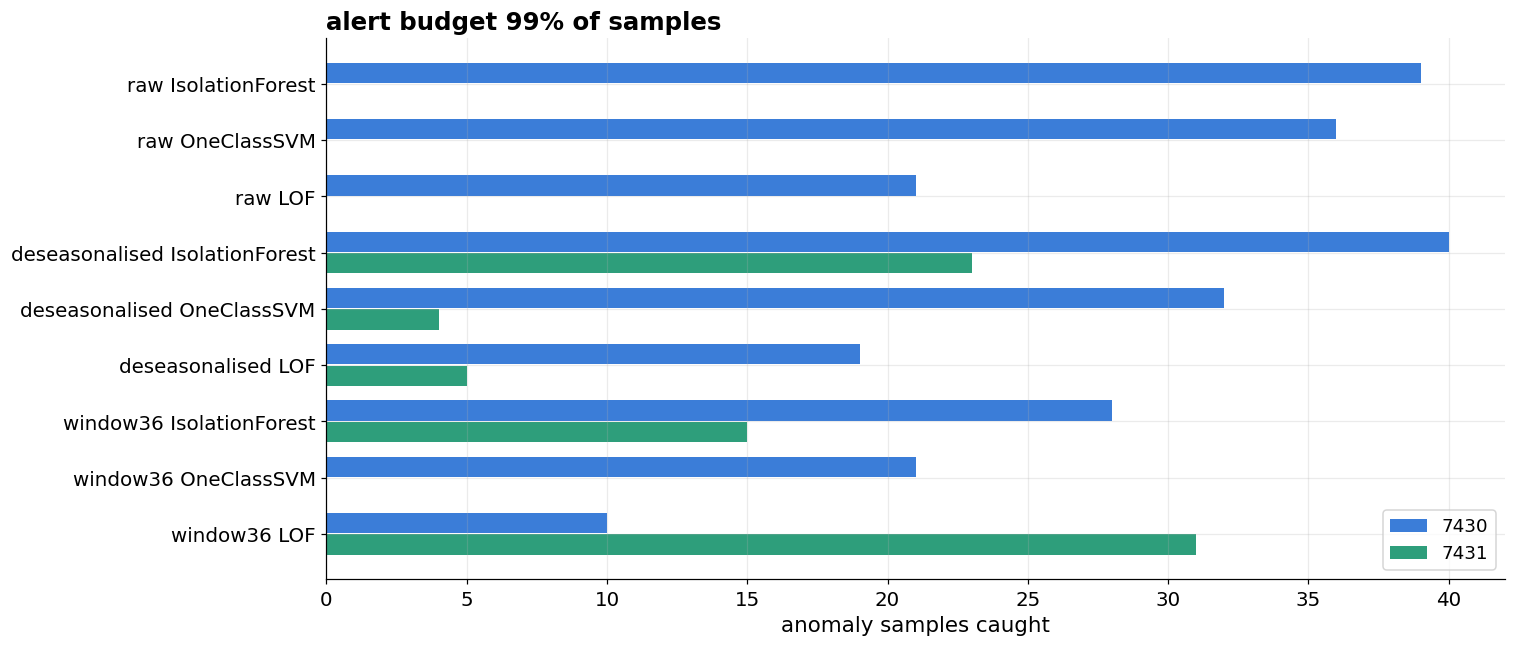

,port,method,alerts,caught,of,precision
0,7431,raw IsolationForest,86,0,36,0.000
1,7431,raw OneClassSVM,87,0,36,0.000
2,7431,raw LOF,87,0,36,0.000
3,7431,deseasonalised IsolationForest,87,23,36,0.264
4,7431,deseasonalised OneClassSVM,87,4,36,0.046
5,7431,deseasonalised LOF,87,5,36,0.057
6,7431,window36 IsolationForest,87,15,36,0.172
7,7431,window36 OneClassSVM,87,0,36,0.000
8,7431,window36 LOF,87,31,36,0.356
9,7430,raw IsolationForest,86,39,40,0.453


In [14]:
summary = (pd.DataFrame(rows).drop_duplicates(subset=["port", "method"])
           .pivot(index="method", columns="port", values="caught").fillna(0).astype(int))
order = [f"{p} {m}" for p in ("raw", "deseasonalised", f"window{N_INPUT}")
         for m in ("IsolationForest", "OneClassSVM", "LOF")]
summary = summary.reindex([m for m in order if m in summary.index])

w, h = plt.rcParams["figure.figsize"]
fig, ax = plt.subplots(figsize=(w, 0.5 * len(summary) + 1.6))
y = np.arange(len(summary))
for k, port in enumerate(summary.columns):
    ax.barh(y + (k - 0.5) * 0.38, summary[port], height=0.36,
            color=[C["signal"], C["peer"]][k % 2], label=port)
ax.set_yticks(y, summary.index)
ax.invert_yaxis()
ax.set(xlabel="anomaly samples caught", title=f"alert budget {BUDGET:.0%} of samples")
ax.legend()
plt.show()

pd.DataFrame(rows).drop_duplicates(subset=["port", "method"])

Read the two ports as two different problems.

- **`port-id7430`, absolute.** Raw scoring already reaches 39 of 40; deseasonalising adds one,
  windowing takes eleven away.
- **`port-id7431`, contextual.** Raw scoring finds nothing; the remedies recover between 4 and 31 of
  36 depending on the pairing.
- **No row wins both columns.**
  - That is the result, and it is more useful than a ranking.
  - Feature engineering that encodes time matters more than the choice of model.
  - Picking it wrong costs you on the anomalies that never needed it.

**The matrix profile is absent from this chart** because it lives in Lab 01 and scores subsequences
rather than samples, so it has no per-sample budget to be cut at. On its own terms it was the
strongest single result across both labs: rank-1 discord on both ports, one parameter, no training,
no scaler, no split.

### Which to reach for first

| situation | first choice |
|---|---|
| a hard limit exists | a rule: safety ceiling, SLO, error budget |
| one signal, clear pattern | a statistical baseline; remove or model the seasonality first |
| several signals interacting | ML, but only after a fixed threshold and a rolling z-score |

These layer rather than compete. A fixed threshold under a statistical baseline under a model is a
normal production stack, not indecision.

## Exercises

Six measurements, then four designs that need what you know about your own network.

### Measure it

1. **Window length.** `N_INPUT` to `12`, then `288`, re-run Step 5.
   - At `288` detection collapses — explain it from the definition of the window.
   - Check against Lab 01 Step 17a.
   - `N_INPUT` arrives through the spec: a permanent change belongs in Lab 01, a temporary one below
     Step 3.
2. **Subsequence length.** `SUBSEQ` in Lab 01 Step 15 to `PERIOD // 4`, then `PERIOD * 2`. Does the
   top discord stay on the anomaly?
3. **CUSUM slack.** `k` to `0.25`, then `3.0`. How does the alarm count move, and which value would
   you defend to an on-call team?
4. **EWMA memory.** `lam` to `0.05`, then `0.8`.
   - Watch alert count *and* delay to first alert.
   - Then remove the `/ limit` and re-run: which λ still fires, and does
     `implied_threshold_if_unscaled` explain which do not?
5. **The cap.** `CAP = 1e6`, effectively removing it.
   - The `q = 0.995` row on all 13 columns comes back to life.
   - What replaces the cap as the failure, and which would you rather debug at 03:00?
6. **Composition rule.** Swap `max(axis=1)` for `mean(axis=1)`, then `(z > 4).sum(axis=1)`.
   - Max ignores agreement, mean dilutes, voting needs a quorum you choose.
   - Score all three at `q = 0.995` and say which you would ship.

### Design it

7. **Which family fits your team?**
   - The real difference is maintenance, not accuracy.
   - A fixed rule needs a human to pick a line per metric, then holds forever.
   - A model needs someone to confirm the training period still represents normal.
   - Which cost can your team carry, and what would make the other affordable?
8. **Explain a model score to your on-call.**
   - A z of 4 is four standard deviations. An isolation score of 0.6384 is indefensible in a review.
   - Draft the two sentences for the alert payload, then decide whether they justify waking someone.
   - If not, that argues for a statistical detector *in front of* the model.
9. **Design the seasonal bucket your traffic has.**
   - Lab 01's `decompose` assumes one daily period.
   - Write the key one service you support would need, and how much history each bucket requires.
10. **Pick the swap that would break production.**
    - Everything downstream of the score is detector-agnostic except the threshold.
    - Write what happens if someone swaps a scoring function and leaves the constant.
    - Then write the check that would have caught it. It is easier to write than the incident review.

In [15]:
# YOUR CODE HERE

## Summary

- **A contract beats a convention.** This lab recomputes no feature and refits no scaler. It asserts
  the frame matches the spec and stops if it does not.
- **A contextual anomaly is invisible to a model with no clock.**
  - Three standard detectors on raw values caught nothing on `port-id7431`.
  - Deseasonalising recovered 23 of 36 with `IsolationForest`; sliding windows recovered 31 with
    `LOF`. Neither changed the model.
- **The framing and the detector are one decision.** On windowed rows, `OneClassSVM` catches 0 where
  `LOF` catches 31.
- **State buys persistence and costs latency.** CUSUM needs no confirmation layer; EWMA is late in
  both directions; both need their scale stated or the threshold silently moves.
- **A guard rail changes the statistics it guards.** The score cap turns a working ranking into a
  constant, and every quantile built on it dies quietly.
- **A change point is an investigation, not a verdict.** The largest level changes this month are
  weekends.

Both labs scored one signal at a time. The anomalies that stayed invisible — the broadcast storm and
the multicast flooding — are visible in a **ratio** between two counters, which is where multivariate
detection starts.